In [33]:
import matplotlib.pyplot as plt
import h5py
from matplotlib import cm
from matplotlib import gridspec
import matplotlib
from matplotlib import colors
from scipy import special

import numpy as np
import copy
from functions import *


def load_obj(name):
    with open('bestfits/' + name + '.pkl', 'rb') as f:
        obj = pickle.load(f)
        print(name+':')
        if 'varied' in name:
            for z in obj.keys():
                print('z = '+z)
                p1, p2, p3, p4, p5, p6 = obj[z]['Transition point'], obj[z]['Pre-disk slope'],\
                                         obj[z]['Pre-disk normalization'], obj[z]['Pre-disk sigma'],\
                                         obj[z]['Post-disk sigma'], obj[z]['Post-disk normalization']
                print(z+' & $10^{'+str(p1)+'}$ & '+str(p2)+' & $10^{'+str(p3)+'}$ & '+str(p4)+' & '+str(p5)+' & '+str(p6)+' \\')
                print('\n')
        else:
            p1, p2, p3, p4, p5, p6 = obj['Transition point'], obj['Pre-disk slope'],\
                                     obj['Pre-disk normalization'], obj['Pre-disk sigma'],\
                                     obj['Post-disk sigma'], obj['Post-disk normalization']
            print('ALL & $10^{'+str(p1)+'}$ & '+str(p2)+' & $10^{'+str(p3)+'}$ & '+str(p4)+' & '+str(p5)+' & '+str(p6)+' \\')
            print('\n')
        return obj

import warnings
warnings.filterwarnings( "ignore")

slopes = np.linspace(0.01,4.0,15)
print(slopes)

[0.01  0.295 0.58  0.865 1.15  1.435 1.72  2.005 2.29  2.575 2.86  3.145
 3.43  3.715 4.   ]


In [6]:
files = [f.split('a')[1].split('.d')[0] for f in glob.glob('ssfrs/ssfr_a*.dat')]
ssfr_a_list = np.array([float(a) for a in files])
ssfr_mass_list = np.array([np.loadtxt("ssfrs/ssfr_a"+f+".dat")[:,0] for f in files])
ssfr_list = [np.loadtxt("ssfrs/ssfr_a"+f+".dat")[:,1] for f in files]

files = [f.split('a')[1].split('.d')[0] for f in glob.glob('smfs/smf_a*.dat')]
smf_a_list = np.array([float(a) for a in files])
smf_mass_list = np.array([np.loadtxt("smfs/smf_a"+f+".dat")[:,0] for f in files])
smf_list = [np.loadtxt("smfs/smf_a"+f+".dat")[:,1] for f in files]

param_file = np.loadtxt("smhm_params.txt")
names = "EFF_0 EFF_0_A EFF_0_A2 EFF_0_Z M_1 M_1_A M_1_A2 M_1_Z ALPHA ALPHA_A ALPHA_A2 ALPHA_Z BETA BETA_A BETA_Z DELTA GAMMA GAMMA_A GAMMA_Z CHI2".split(" ");
params = dict(zip(names, param_file[:,1]))


def plot_obs(ax, phantom = False):
    objs = []
    labels = []
    colors = {'B-Band':'pink', 'UV-1450A':'seagreen', 'Hard-X':'royalblue', 'Soft-X':'grey', 'Mid-IR':'olive'}
    cleanlabel = {'B-Band':'B Band', 'UV-1450A':r'UV 1450$\rm\AA$', 'Hard-X':'Hard X-ray', 'Soft-X':'Soft X-ray', 'Mid-IR':'Mid IR'}
    cs, ms, lw, ct = 1.5, 2.5, 1, 1
    
    fobs = h5py.File("SHEN_obs_collect.h5py", "r")
    for band in fobs["z="+str(z)]:
        index = "z="+str(z)+"/"+band
        x = fobs[index]['x'][:]
        y = fobs[index]['y'][:]
        xerr = fobs[index]['xerr'][:]
        yerr = fobs[index]['yerr'][:]
        xerrcor = np.zeros((2,len(xerr)))
        xerrcor[1,:] = 10**(x + xerr) - 10**x
        xerrcor[0,:] = 10**x - 10**(x - xerr)

        b = ax.errorbar(10**x, y, yerr = yerr, c=colors[band], fmt = 'o', fillstyle='none', capsize=cs, ms=ms, lw=lw, capthick=ct, zorder=2, alpha = 1)
        objs.append(b)
        labels.append(cleanlabel[band])
    fobs.close()
    
    if phantom:
        xtot = []
        ya = []
        yaerr = []
        fobs = h5py.File("SHEN_obs_collect.h5py", "r")
        for band in fobs["z="+str(z)]:
            index = "z="+str(z)+"/"+band
            xtot.extend(fobs[index]['x'][:]) ##log10 of bolometric L in erg/s
            ya.extend(fobs[index]['y'][:]) ##log10 of QLF
            yaerr.extend(fobs[index]['yerr'][:]) ##error on that
        fobs.close()

        xobscut = min(np.asarray(xtot))
        xphan = np.linspace(40, 44, 9)
        if round(xobscut) < xobscut:
            xphan = xphan[xphan <= round(xobscut)]
        else:
            xphan = xphan[xphan < round(xobscut)]
        yphan, yphanerr, _, _, _ = Shen_fit_uncer(z, np.log10(10**xphan/3.8e33))

        p = ax.errorbar(10**xphan, yphan, yerr = yphanerr, c='cyan', fmt = 'o', fillstyle='none',  capsize=cs, ms=ms, lw=lw, capthick=ct,  zorder=2)
        objs.append(p)
        labels.append('Phantom points')

    return objs, labels

## Test capping at the Eddington Luminosity. 

In [30]:
class QLF_Lcap():
    def __init__(self, z, bins):


        self.z = float(z)
        self.a = 1.0/(1.0+self.z)
        self.bins = bins

        self.StellBins = np.linspace(3.0, 12.5, int((12.5 - 3.0) / self.bins))
        
        #### extract ssfr
        closest_a = np.argmin(np.abs(ssfr_a_list - self.a))
        ssfrs = np.array(ssfr_list[closest_a])
        nonzero = (ssfrs != 0)
        masses = np.array(ssfr_mass_list[closest_a])
        self.SSFRs = 10**np.interp(self.StellBins, masses[nonzero], np.log10(ssfrs[nonzero]))
        
        #### extrapolate out to high M*
        slope = (np.log10(ssfrs[nonzero][-1]) - np.log10(ssfrs[nonzero][-2])) / (masses[nonzero][-1] - masses[nonzero][-2])
        inter = np.log10(ssfrs[nonzero][-1]) - slope * masses[nonzero][-1]
        gtzero = (self.StellBins >= masses[nonzero][-1])
        self.SSFRs[gtzero] = 10**(self.StellBins[gtzero]*slope + inter)
        
        #### extrapolate out to low M*
        slope = (np.log10(ssfrs[1]) - np.log10(ssfrs[0])) / (masses[1] - masses[0])
        inter = np.log10(ssfrs[0]) - slope * masses[0]
        ltavail = (self.StellBins < masses[0])
        self.SSFRs[ltavail] = 10**(self.StellBins[ltavail]*slope + inter)
        
        
        ### extract smf
        closest_a = np.argmin(np.abs(smf_a_list - self.a))
        smf = np.array(smf_list[closest_a])
        nonzero = (smf != 0)
        masses = np.array(smf_mass_list[closest_a])
        self.dNdlogMstar = 10**np.interp(self.StellBins, masses[nonzero], np.log10(smf[nonzero]))
        
        #### extrapolate out to high M*
        slope = (np.log10(smf[nonzero][-1]) - np.log10(smf[nonzero][-2])) / (masses[nonzero][-1] - masses[nonzero][-2])
        inter = np.log10(smf[nonzero][-1]) - slope * masses[nonzero][-1]
        self.dNdlogMstar[gtzero] = 10**(self.StellBins[gtzero]*slope + inter)
        
        #### extrapolate out to low M*
        slope = (np.log10(smf[1]) - np.log10(smf[0])) / (masses[1] - masses[0])
        inter = np.log10(smf[0]) - slope * masses[0]
        self.dNdlogMstar[ltavail] = 10**(self.StellBins[ltavail]*slope + inter)
        
        self.dNdlnMstar = self.dNdlogMstar/np.log(10)
        


    def get_Mbh(self, logMstar0, slope_low = 0.2, norm_from_local =4.0, approx_local = True, norm_local = 8.2, local_slope = 1.12):
        norm = [11, norm_local]
        
        self.logMstar0 = logMstar0
        logMstar = self.StellBins
        logMbh = logMstar * 0
        slopes = logMstar * 0

        if approx_local == False:
            logMbh0 = logMstar0*local_slope - norm[0]*local_slope + norm[1] - norm_from_local
            my_norm = [logMstar0, logMbh0]
            post_params = [local_slope, logMbh0 - local_slope*logMstar0]
            pre_params = [slope_low, my_norm[1] - my_norm[0] * slope_low]

        else:
            logMbh0 = logMstar0 + norm[1] - norm[0] - norm_from_local
            my_norm = [logMstar0, logMbh0]
            post_params = [1, logMbh0 - logMstar0]
            pre_params = [slope_low, my_norm[1] - my_norm[0] * slope_low]

        post = (logMstar > logMstar0)
        pre = (logMstar <= logMstar0)
        Ms = 10**logMstar
        Ms0 = 10**logMstar0
        Mbh0 = 10**logMbh0
        beta = post_params[0]
        alpha = 10**norm[1] / 10**(norm[0]*beta)

        Mbh = Mbh0 + alpha * Ms[post]**(beta-1) * (Ms[post] - Ms0)
        logMbh[post] = np.log10(Mbh)
        slopes[post] = alpha * beta * Ms[post]**beta / Mbh

        logMbh[pre] = logMstar[pre] * pre_params[0] + pre_params[1]
        slopes[pre] = pre_params[0]

        
        self.slopes = slopes
        self.BHBins = logMbh
        self.pre = pre
        self.post = post
        self.mmax = post_params[0]
        ## SSFR are in yr^-1
        self.SBHARs = self.slopes * (self.SSFRs / 3.154e7) ## s^-1
        self.MdotBH = self.SBHARs * (10**self.BHBins * 2e33) ## g/s
        self.Ledd = 1.3e38 * 10**self.BHBins ## erg/s
        self.Mdotedd = self.Ledd / (.1 * (2.99e10)**2) ## g/s


    def get_Mdotbh(self, vals, files = files):

        lnxsig = vals[0]
        Mdotbh = vals[1]
        
        mu_lnX = -0.5 * lnxsig**2
        mu_lnMdotbh = mu_lnX + np.log(Mdotbh) #g/s
        
        return mu_lnMdotbh, lnxsig, 


    def gauss_Mdot(self, lnMdotbh):
        ### I input the MdotBH value we are seeking.
        # lnMdotBH = ln[Lbol/(eps*c^2)]
        
        ### These are the mu_lnMdotBH and sig_lnMdotBH values corresponding M* values
        mu = self.Mdot_mu_sig[:,0] # mu_lnMdotBH(M*)
        sig = self.Mdot_mu_sig[:,1] # sigma_lnMdotBH(M*)
        
        ### These are the MdotEdd values corresponding to M* values.
        log_Mdotedd = np.log(self.Mdotedd) # MdotEdd(M*)
        
        ### Calculate p(lnLbol|lnM*)
        sig2 = sig*sig
        p = ( 1/np.sqrt(2.0 * np.pi * sig2) ) * np.exp( -(lnMdotbh - mu)**2.0 / (2.0 * sig2) )
        
        ### Find where BHs are accreting above their Eddington rates and set their p value equal to 0.
        ### This is essentially redifing the range of the integral in case (i)
        Lbol_gt_Ledd = np.where(lnMdotbh[0] > log_Mdotedd)[0]
        p[Lbol_gt_Ledd] = 0
        
        return p
    
    def L_Mdot(self, lnMdotbh):
        ### I input the MdotBH value we are seeking.

        ### These are the mu_lnMdotBH and sig_lnMdotBH values corresponding M* values
        mu = self.Mdot_mu_sig[:,0] # mu_lnMdotBH(M*)
        sig = self.Mdot_mu_sig[:,1] # sigma_lnMdotBH(M*)
        
        ### These are the MdotEdd values corresponding to M* values.
        log_Mdotedd = np.log(self.Mdotedd) # MdotEdd(M*)
        
        ### Find where BHs are accreting above their Eddington rates.
        ### I do this to find M*tilde since this list should range from M* = 0 to M* = M*tilde.
        Lbol_gt_Ledd = np.where(lnMdotbh[0] > log_Mdotedd)[0] # all of these BHs will be accreting at their MdotEdd value 
                                                              # because they can NOT accrete at lnMdotbh
        if Lbol_gt_Ledd.size == 0:
            L_Mtilde = 0.
        else:
            Mtilde = Lbol_gt_Ledd[-1] #M*tilde is the BH for which its Eddington accreton value Mdotedd ~= MdotBH (the luminosity we were originally seeking)
            #L(M*tilde) from case (ii)
            L_Mtilde = 0.5*special.erfc( (log_Mdotedd[Mtilde] - mu[Mtilde]) / (np.sqrt(2) * sig[Mtilde]) ) * self.dNdlnMstar[Mtilde] / self.slopes[Mtilde]
            
        return L_Mtilde
        


    def get_dNdlnL(self, L, lnxsigs): #input luminosity in log10 space in units of solar mass
        
        lnxsig_list = self.StellBins * 0
        lnxsig_list[self.pre] = lnxsigs[0]
        lnxsig_list[self.post] = lnxsigs[1]
        ### start transition at the M*crit value
        critpoint = np.argmin(np.abs(self.StellBins - self.logMstar0))
        ### end transistion 0.5 dex after that value
        endtran = np.argmin(np.abs(self.StellBins - (self.logMstar0 + 0.5)))
        lintrans = np.linspace(lnxsigs[0], lnxsigs[1], len(lnxsig_list[critpoint-1:endtran]))
        lnxsig_list[critpoint-1:endtran] = lintrans

        vals = np.zeros((len(self.StellBins), 3))
        vals[:,0] = lnxsig_list
        vals[:,1] = self.MdotBH
        
        self.Mdot_mu_sig = np.apply_along_axis(self.get_Mdotbh, 1, vals)

        ### Based on the L values input, calculate the MdotBH values required to produce such luminosities.
        self.lnMdotbh_list = (np.asarray(L) + np.log10(3.9e33)) * np.log(10) - np.log(0.1*2.99e10**2)

        ### I convert the stellar bins size to log base e for the calculation with the log base e stellar mass function and log base e sigmas
        ### Calculate the probability values for the integral in case (i)
        probs = np.apply_along_axis(self.gauss_Mdot, 1, self.lnMdotbh_list.reshape(len(self.lnMdotbh_list),1))
        ### Integral in case (i)
        self.intvals = probs * self.dNdlnMstar * (self.StellBins[1] - self.StellBins[0]) * np.log(10)

        ### Calculate the L(M*tilde) values in case (ii)
        self.L_Mtildestar = np.apply_along_axis(self.L_Mdot, 1, self.lnMdotbh_list.reshape(len(self.lnMdotbh_list),1))
        
        #### I produce two QLFs one in log base e and the other in log base 10
        #### I add the values from case (i) and case (ii) together to produce the final QLF 
        self.dNdlnL = np.sum(self.intvals, axis = 1) + self.L_Mtildestar #dN/dlnLbol = integral + L(M*tilde)
        self.dNdlnL_noadd = np.sum(self.intvals, axis = 1) 
        
        self.dNdlogL = self.dNdlnL * np.log(10)
        


## Plotting

3.4 ms ± 46.7 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


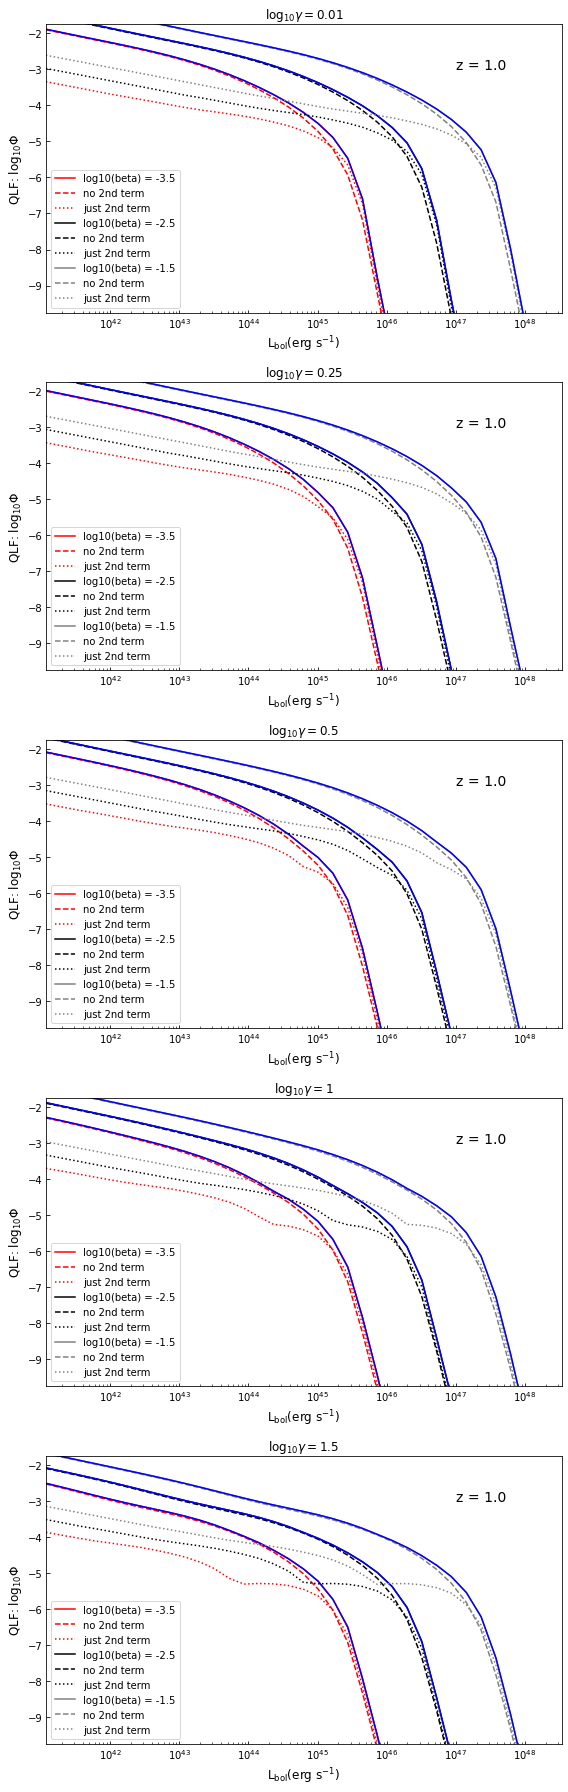

In [10]:
%matplotlib inline
fig = plt.figure(figsize=(8,25))
gs = gridspec.GridSpec(5, 1)

bins = 0.0005
z = 1.0
lums = np.linspace(5,15.5,50)
# lums = np.log10(np.logspace(10,15,500))
lumsp = 10**lums*3.8e33

crit_fit = 10.75
alpha_fit = 1
gamma_fit = 1.5
beta_fit = -1.5
pre_fit, post_fit = 2.5, 1.5

for gamma_fit, xi, yi in zip([0.01, 0.25, 0.5, 1, 1.5], [0,1,2,3,4], [0,0,0,0,0]):

    ax = fig.add_subplot(gs[xi,yi])
    for beta_fit, color in zip([-3.5, -2.5, -1.5], ['r', 'k', 'grey']):
        qlf = QLF_Lcap(z, bins)
        qlf.get_Mbh(crit_fit, alpha_fit, gamma_fit, norm_local = 11+beta_fit)
        qlf.get_dNdlnL(lums, [pre_fit, post_fit])
        ax.plot(lumsp, np.log10(qlf.dNdlogL), c=color, label = 'log10(beta) = '+str(beta_fit), lw=1.5)
        ax.plot(lumsp, np.log10(qlf.dNdlnL_noadd * np.log(10)), c=color, label = 'no 2nd term', lw=1.5, ls='dashed')
        ax.plot(lumsp, np.log10(qlf.L_Mtildestar * np.log(10)), c=color, label = 'just 2nd term', lw=1.5, ls='dotted')
        jitQLF = get_QLF(list(lums), logMstar0 = crit_fit, slope_low = alpha_fit, norm_from_local = gamma_fit, norm_local = 11+beta_fit, presig = pre_fit, postsig = post_fit)
        ax.plot(lumsp, np.log10(jitQLF), color='b')
    ax.axis([10**7.5*3.8e33,10**14.95*3.8e33,-9.75,-1.75])
    ax.set_xlabel(r'$\rmL_{bol} (erg\ s^{-1})$', fontsize=12)
    ax.set_ylabel(r'QLF: $\log_{10} \Phi$', fontsize =12)
    ax.text(10**47,-3,'z = '+str(z), fontsize = 14)
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
    # objs, labels = plot_obs(ax, phantom = True)
    ax.set_title(r'$\log_{10} \gamma = $'+str(gamma_fit))
    ax.legend()
plt.tight_layout()
# plt.savefig('PLOTS/L_cap_test_varybeta+gamma.pdf')

%timeit get_QLF(list(lums), logMstar0 = crit_fit, slope_low = alpha_fit, norm_from_local = gamma_fit, norm_local = 11+beta_fit, presig = pre_fit, postsig = post_fit)



In [1]:
from numba import jit
import numpy as np
import glob
from scipy import special

lums = np.linspace(5,15.5,50)
crit_fit = 10.75
alpha_fit = 1
gamma_fit = 1.5
beta_fit = -1.5
pre_fit, post_fit = 2.5, 1.5


z = 1
qlf_bins = 0.005     
a = 1.0/(1.0+z)

files = [f.split('a')[1].split('.d')[0] for f in glob.glob('ssfrs/ssfr_a*.dat')]
ssfr_a_list = np.array([float(a) for a in files])
ssfr_mass_list = np.array([np.loadtxt("ssfrs/ssfr_a"+f+".dat")[:,0] for f in files])
ssfr_list = [np.loadtxt("ssfrs/ssfr_a"+f+".dat")[:,1] for f in files]

files = [f.split('a')[1].split('.d')[0] for f in glob.glob('smfs/smf_a*.dat')]
smf_a_list = np.array([float(a) for a in files])
smf_mass_list = np.array([np.loadtxt("smfs/smf_a"+f+".dat")[:,0] for f in files])
smf_list = [np.loadtxt("smfs/smf_a"+f+".dat")[:,1] for f in files]

param_file = np.loadtxt("smhm_params.txt")
names = "EFF_0 EFF_0_A EFF_0_A2 EFF_0_Z M_1 M_1_A M_1_A2 M_1_Z ALPHA ALPHA_A ALPHA_A2 ALPHA_Z BETA BETA_A BETA_Z DELTA GAMMA GAMMA_A GAMMA_Z CHI2".split(" ");
params = dict(zip(names, param_file[:,1]))

StellBins = np.linspace(3.0, 12.5, int((12.5 - 3.0) / qlf_bins))

closest_a = np.argmin(np.abs(ssfr_a_list - a))

#### extract ssfr
ssfrs = np.array(ssfr_list[closest_a])
nonzero = (ssfrs != 0)
masses = np.array(ssfr_mass_list[closest_a])
SSFRs = 10**np.interp(StellBins, masses[nonzero], np.log10(ssfrs[nonzero]))

#### extrapolate out to high M*
slope = (np.log10(ssfrs[nonzero][-1]) - np.log10(ssfrs[nonzero][-2])) / (masses[nonzero][-1] - masses[nonzero][-2])
inter = np.log10(ssfrs[nonzero][-1]) - slope * masses[nonzero][-1]
gtzero = (StellBins >= masses[nonzero][-1])
SSFRs[gtzero] = 10**(StellBins[gtzero]*slope + inter)

#### extrapolate out to low M*
slope = (np.log10(ssfrs[1]) - np.log10(ssfrs[0])) / (masses[1] - masses[0])
inter = np.log10(ssfrs[0]) - slope * masses[0]
ltavail = (StellBins < masses[0])
SSFRs[ltavail] = 10**(StellBins[ltavail]*slope + inter)


### extract smf
closest_a = np.argmin(np.abs(smf_a_list - a))
smf = np.array(smf_list[closest_a])
nonzero = (smf != 0)
masses = np.array(smf_mass_list[closest_a])
dNdlogMstar = 10**np.interp(StellBins, masses[nonzero], np.log10(smf[nonzero]))

#### extrapolate out to high M*
slope = (np.log10(smf[nonzero][-1]) - np.log10(smf[nonzero][-2])) / (masses[nonzero][-1] - masses[nonzero][-2])
inter = np.log10(smf[nonzero][-1]) - slope * masses[nonzero][-1]
dNdlogMstar[gtzero] = 10**(StellBins[gtzero]*slope + inter)

#### extrapolate out to low M*
slope = (np.log10(smf[1]) - np.log10(smf[0])) / (masses[1] - masses[0])
inter = np.log10(smf[0]) - slope * masses[0]
dNdlogMstar[ltavail] = 10**(StellBins[ltavail]*slope + inter)

dNdlnMstar = dNdlogMstar/np.log(10)
##################################################################################################
    

In [4]:
@jit(nopython=True)
def get_QLF(L, logMstar0 = None, slope_low = None, norm_from_local = None, norm_local = 8.2, approx_local = True, presig = None, postsig = None):

    bins = qlf_bins
    norm = [11, norm_local]

    logMstar = StellBins
    BHBins = logMstar * 0
    slopes = logMstar * 0

    logMbh0 = logMstar0 + norm[1] - norm[0] - norm_from_local
    my_norm = [logMstar0, logMbh0]
    post_params = [1, logMbh0 - logMstar0]
    pre_params = [slope_low, my_norm[1] - my_norm[0] * slope_low]

    post = (logMstar > logMstar0)
    pre = (logMstar <= logMstar0)
    Ms = 10**logMstar
    Ms0 = 10**logMstar0
    Mbh0 = 10**logMbh0
    beta = post_params[0]
    alpha = 10**norm[1] / 10**(norm[0]*beta)

    Mbh = Mbh0 + alpha * Ms[post]**(beta-1) * (Ms[post] - Ms0)
    BHBins[post] = np.log10(Mbh)
    slopes[post] = alpha * beta * Ms[post]**beta / Mbh

    BHBins[pre] = logMstar[pre] * pre_params[0] + pre_params[1]
    slopes[pre] = pre_params[0]
    
    LEdd = 1.3e38 * 10**BHBins ## erg/s
    MdotEdd = LEdd / (.1 * (2.99e10)**2) ## g/s
    logMdotEdd = np.log(MdotEdd)
    
    ## SSFR are in yr^-1
    SBHARs = slopes * (SSFRs / 3.154e7) ## s^-1
    MdotBH = SBHARs * (10**BHBins * 2e33) ## g/s

    lnxsig_list = StellBins * 0
    lnxsig_list[pre] = presig
    lnxsig_list[post] = postsig
    ### start transition at the M*crit value
    critpoint = np.argmin(np.abs(StellBins - logMstar0))
    ### end transistion 0.5 dex after that value
    endtran = np.argmin(np.abs(StellBins - (logMstar0 + 0.5)))
    lintrans = np.linspace(presig, postsig, len(lnxsig_list[critpoint-1:endtran]))
    lnxsig_list[critpoint-1:endtran] = lintrans
  
    MU_LIST = (-0.5 * lnxsig_list**2) + np.log(MdotBH)
    SIG_LIST = lnxsig_list
        
    lnMdotbh_list = (np.asarray(L) + np.log10(3.9e33)) * np.log(10) - np.log(0.1*2.99e10**2)

    intvals = []
    for mdot in lnMdotbh_list:
        p = ( 1/np.sqrt(2.0 * np.pi * SIG_LIST*SIG_LIST) ) * np.exp( -(mdot - MU_LIST)**2.0 / (2.0 * SIG_LIST*SIG_LIST) )
        Lbol_gt_Ledd = np.where(mdot > logMdotEdd)[0]
#         Lbol_gt_Ledd = (mdot > logMdotEdd)
        p[Lbol_gt_Ledd] = 0
        intvals.append(p * dNdlnMstar * (StellBins[1] - StellBins[0]) * np.log(10))

    dNdlnL = []
    for val in intvals:
        totval = 0.0 
        for n in val:
            totval = totval + n
        dNdlnL.append(totval)
    
    L_Mtildestar = []
    for mdot in lnMdotbh_list:
        Lbol_gt_Ledd = np.where(mdot > logMdotEdd)[0]
        if Lbol_gt_Ledd.size == 0:
            L_Mtilde = 0.
        else:
            Mtilde = Lbol_gt_Ledd[-1]
            L_Mtilde = 0.5*special.erfc( (logMdotEdd[Mtilde] - MU_LIST[Mtilde]) / (np.sqrt(2) * SIG_LIST[Mtilde]) ) * dNdlnMstar[Mtilde] / slopes[Mtilde]
        L_Mtildestar.append(L_Mtilde)
            
    dNdlogL = ( np.array(dNdlnL) + np.array(L_Mtildestar) ) * np.log(10)
    return dNdlogL

get_QLF(lums, logMstar0 = crit_fit, slope_low = alpha_fit, norm_from_local = gamma_fit, norm_local = 11+beta_fit, presig = pre_fit, postsig = post_fit)


array([2.38867752e-01, 1.93428850e-01, 1.56666858e-01, 1.26989454e-01,
       1.02918643e-01, 8.34428432e-02, 6.76818104e-02, 5.49236541e-02,
       4.45934620e-02, 3.62484742e-02, 2.94693327e-02, 2.39791219e-02,
       1.95329736e-02, 1.59312963e-02, 1.30104798e-02, 1.06429404e-02,
       8.70347153e-03, 7.11113937e-03, 5.79527998e-03, 4.70269665e-03,
       3.79306743e-03, 3.03634716e-03, 2.40963344e-03, 1.90121614e-03,
       1.49718740e-03, 1.18414997e-03, 9.44897488e-04, 7.64179371e-04,
       6.22250763e-04, 5.06631816e-04, 4.07454406e-04, 3.18441403e-04,
       2.38843527e-04, 1.71107994e-04, 1.16572023e-04, 7.88274260e-05,
       5.05778195e-05, 2.98093507e-05, 1.62086209e-05, 7.78433427e-06,
       2.86169521e-06, 6.00273829e-07, 4.38811686e-08, 1.14182080e-09,
       1.90615957e-11, 4.60597456e-13, 1.00936803e-15, 8.91949273e-19,
       3.42857401e-22, 7.83130378e-26])

## Plotting L_cap best fit

In [25]:
def get_null(FILE):
    f = h5py.File(FILE, "r") 
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    alpha = f['slope_low'][:]
    transition = f['logMstar0'][:]
    chi2_grid = f['chi2_grid'][:].T
    f.close()

    for index, value in np.ndenumerate(chi2_grid):
        if siglnX2[index[3]] > siglnX1[index[4]]:# or transition[index[5]] > 10.:#alpha[index[2]] > 1 or alpha[index[2]] < 0.5:
            chi2_grid[index] = 1e10

    null = np.where(chi2_grid == 1e10)
    
    return null

def get_null_alpha1(FILE):
    f = h5py.File(FILE, "r") 
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    alpha = f['slope_low'][:]
    transition = f['logMstar0'][:]
    chi2_grid = f['chi2_grid'][:].T
    f.close()

    for index, value in np.ndenumerate(chi2_grid):
        if siglnX2[index[3]] > siglnX1[index[4]] or alpha[index[2]] > 1.3 or alpha[index[2]] < 0.7:
            chi2_grid[index] = 1e10

    null = np.where(chi2_grid == 1e10)
    
    return null

redshifts = [0.5, 1.0, 2.0, 3.0, 4.0]
filename = '../ceph/QLF_proj/output/chi2_phantom_2P_Lcap_lowres'

print('Generating null grids.')
null = get_null(filename+'_z'+str(redshifts[0])+'.h5py')
null_alpha1 = get_null_alpha1(filename+'_z'+str(redshifts[0])+'.h5py')

Generating null grids.


In [17]:

num_of_points = {'z=0.5':0,'z=1.0':0,'z=2.0':0,'z=3.0':0,'z=4.0':0, 'fixed':0}

fobs = h5py.File("SHEN_obs_collect.h5py", "r")
for z in [0.5,1.0,2.0,3.0,4.0]:
    for band in fobs["z="+str(z)]:
        index = "z="+str(z)+"/"+band
        x = fobs[index]['x'][:]
        y = fobs[index]['y'][:]
        num_of_points['z='+str(z)] += len(x)
        num_of_points['fixed'] += len(x)
fobs.close()
print(num_of_points)

num_of_points_phantom = {'z=0.5':0,'z=1.0':0,'z=2.0':0,'z=3.0':0,'z=4.0':0, 'fixed':0}
for z in [0.5,1.0,2.0,3.0,4.0]:
    xtot = []
    ya = []
    yaerr = []
    fobs = h5py.File("SHEN_obs_collect.h5py", "r")
    for band in fobs["z="+str(z)]:
        index = "z="+str(z)+"/"+band
        xtot.extend(fobs[index]['x'][:]) ##log10 of bolometric L in erg/s
        ya.extend(fobs[index]['y'][:]) ##log10 of QLF
        yaerr.extend(fobs[index]['yerr'][:]) ##error on that
    fobs.close()

    xobscut = min(np.asarray(xtot))
    xphan = np.linspace(40, 44, 9)
    if round(xobscut) < xobscut:
        xphan = xphan[xphan <= round(xobscut)]
    else:
        xphan = xphan[xphan < round(xobscut)]
    num_of_points_phantom['z='+str(z)] += len(xphan)
    num_of_points_phantom['fixed'] += len(xphan)
print(num_of_points_phantom)    

totpoints = num_of_points_phantom['fixed']+num_of_points['fixed']

print('Total number of points fit:',totpoints)


{'z=0.5': 174, 'z=1.0': 176, 'z=2.0': 177, 'z=3.0': 146, 'z=4.0': 83, 'fixed': 756}
{'z=0.5': 3, 'z=1.0': 4, 'z=2.0': 6, 'z=3.0': 8, 'z=4.0': 8, 'fixed': 29}
Total number of points fit: 785


In [37]:
bulge=False

print('Combining grids.')
for z in redshifts:
    f = h5py.File(filename+'_z'+str(z)+'.h5py', "r") 
    if bulge:
        transition = f['logMb0'][:]
    else:
        transition = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    slope_low = f['slope_low'][:]
    norm_from_local = f['norm_from_local'][:]
    norm_of_local = f['norm_of_local'][:]
    if z == redshifts[0]:
        chi2_grid = f['chi2_grid'][:].T
    else:
        chi2_grid += f['chi2_grid'][:].T
    f.close()


reduced_chi2 = chi2_grid/totpoints
reduced_chi2_alpha1 = chi2_grid/totpoints
print('Setting null points.')
reduced_chi2[null] = 1e15
reduced_chi2_alpha1[null_alpha1] = 1e15

print('Finding best fit values.')
minval = np.amin(reduced_chi2)
minind = np.where(reduced_chi2 == minval)

print('chi2 reduced =', minval)

beta_fit = norm_of_local[minind[0][0]] 
gamma_fit = norm_from_local[minind[1][0]]
alpha_fit = slope_low[minind[2][0]]
post_fit = siglnX2[minind[3][0]]
pre_fit = siglnX1[minind[4][0]]
crit_fit = transition[minind[5][0]]  

minval_alpha1 = np.amin(reduced_chi2_alpha1)
minind_alpha1 = np.where(reduced_chi2_alpha1 == minval_alpha1)

beta_fit_alpha1 = norm_of_local[minind_alpha1[0][0]] 
gamma_fit_alpha1 = norm_from_local[minind_alpha1[1][0]]
alpha_fit_alpha1 = slope_low[minind_alpha1[2][0]]
post_fit_alpha1 = siglnX2[minind_alpha1[3][0]]
pre_fit_alpha1 = siglnX1[minind_alpha1[4][0]]
crit_fit_alpha1 = transition[minind_alpha1[5][0]]  

print('chi2 reduced (alpha1) =', minval_alpha1)

print(beta_fit, gamma_fit, alpha_fit, post_fit, pre_fit, crit_fit)
print(beta_fit_alpha1, gamma_fit_alpha1, alpha_fit_alpha1, post_fit_alpha1, pre_fit_alpha1, crit_fit_alpha1)

Combining grids.
Setting null points.
Finding best fit values.
chi2 reduced = 8.403994211793872
chi2 reduced (alpha1) = 11.329349973294809
-1.5 0.01 2.005 2.9000000000000004 2.9000000000000004 12.0
-1.5 1.1500000000000001 1.1500000000000001 3.2500000000000004 3.2500000000000004 11.142857142857142


In [19]:
def plot_obs(ax, phantom = False):
    objs = []
    labels = []
    colors = {'B-Band':'pink', 'UV-1450A':'seagreen', 'Hard-X':'royalblue', 'Soft-X':'grey', 'Mid-IR':'olive'}
    cleanlabel = {'B-Band':'B Band', 'UV-1450A':r'UV 1450$\rm\AA$', 'Hard-X':'Hard X-ray', 'Soft-X':'Soft X-ray', 'Mid-IR':'Mid IR'}
    cs, ms, lw, ct = 1.5, 2.5, 1, 1
    
    fobs = h5py.File("SHEN_obs_collect.h5py", "r")
    for band in fobs["z="+str(z)]:
        index = "z="+str(z)+"/"+band
        x = fobs[index]['x'][:]
        y = fobs[index]['y'][:]
        xerr = fobs[index]['xerr'][:]
        yerr = fobs[index]['yerr'][:]
        xerrcor = np.zeros((2,len(xerr)))
        xerrcor[1,:] = 10**(x + xerr) - 10**x
        xerrcor[0,:] = 10**x - 10**(x - xerr)

        b = ax.errorbar(10**x, y, yerr = yerr, c=colors[band], fmt = 'o', fillstyle='none', capsize=cs, ms=ms, lw=lw, capthick=ct, zorder=2, alpha = 1)
        objs.append(b)
        labels.append(cleanlabel[band])
    fobs.close()
    
    if phantom:
        xtot = []
        ya = []
        yaerr = []
        fobs = h5py.File("SHEN_obs_collect.h5py", "r")
        for band in fobs["z="+str(z)]:
            index = "z="+str(z)+"/"+band
            xtot.extend(fobs[index]['x'][:]) ##log10 of bolometric L in erg/s
            ya.extend(fobs[index]['y'][:]) ##log10 of QLF
            yaerr.extend(fobs[index]['yerr'][:]) ##error on that
        fobs.close()

        xobscut = min(np.asarray(xtot))
        xphan = np.linspace(40, 44, 9)
        if round(xobscut) < xobscut:
            xphan = xphan[xphan <= round(xobscut)]
        else:
            xphan = xphan[xphan < round(xobscut)]
        yphan, yphanerr, _, _, _ = Shen_fit_uncer(z, np.log10(10**xphan/3.8e33))

        p = ax.errorbar(10**xphan, yphan, yerr = yphanerr, c='cyan', fmt = 'o', fillstyle='none',  capsize=cs, ms=ms, lw=lw, capthick=ct,  zorder=2)
        objs.append(p)
        labels.append('Phantom points')

    return objs, labels

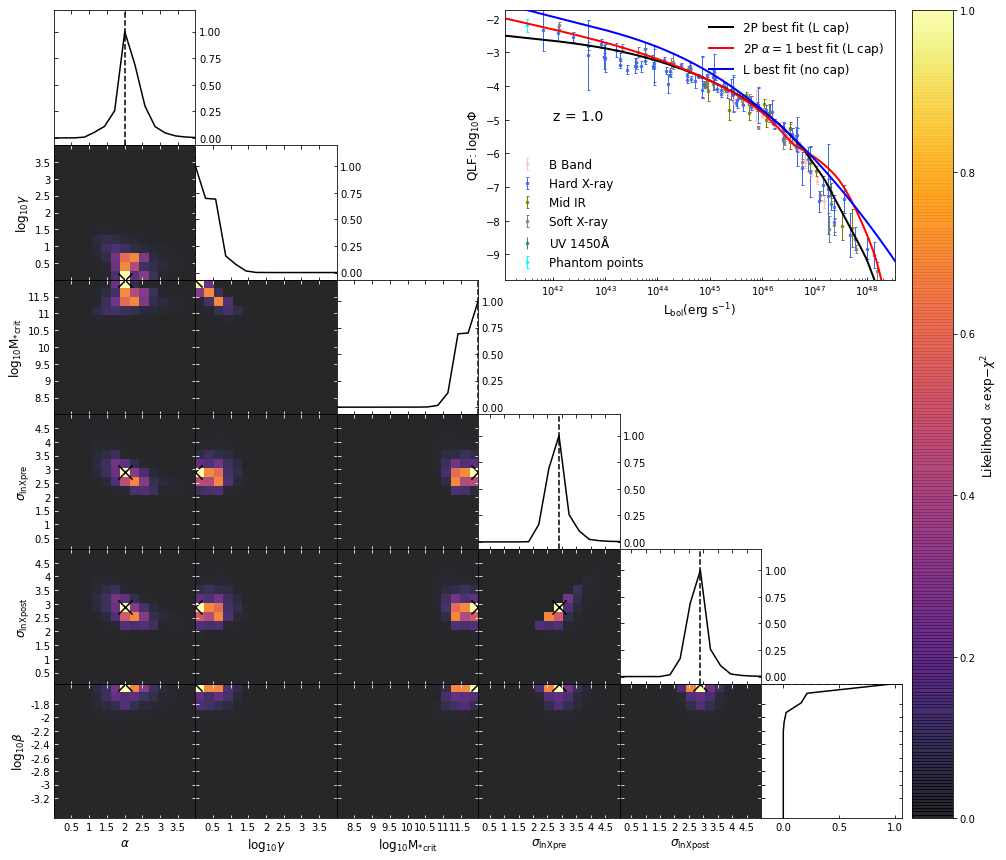

In [35]:
plt.close('all')


fig = plt.figure(figsize=(15,12))
gs = gridspec.GridSpec(6, 6)

likelihood = np.exp(-reduced_chi2)

axj = [0,1,2,3,4,0,1,2,3,0,1,2,0,1,0]
axi = [5,5,5,5,5,4,4,4,4,3,3,3,2,2,1]
axes_l = []

extents = [\
           [slope_low[0], slope_low [-1], norm_of_local[-1], norm_of_local[0]],\
           [norm_from_local[0], norm_from_local[-1], norm_of_local[-1], norm_of_local[0]],\
           [transition[0], transition[-1], norm_of_local[-1], norm_of_local[0]],\
           [siglnX1[0], siglnX1[-1], norm_of_local[-1], norm_of_local[0]],\
           [siglnX2[0], siglnX2[-1], norm_of_local[-1], norm_of_local[0]],\
           [slope_low[0], slope_low[-1], siglnX2[-1], siglnX2[0]],\
           [norm_from_local[0], norm_from_local[-1], siglnX2[-1], siglnX2[0]],\
           [transition[0], transition[-1], siglnX2[-1], siglnX2[0]],\
           [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]],\
           [slope_low[0], slope_low[-1], siglnX1[-1], siglnX1[0]],\
           [norm_from_local[0], norm_from_local[-1], siglnX1[-1], siglnX1[0]],\
           [transition[0], transition[-1], siglnX1[-1], siglnX1[0]],\
           [slope_low[0], slope_low[-1], transition[-1], transition[0]],\
           [norm_from_local[0], norm_from_local[-1], transition[-1], transition[0]],\
           [slope_low[0], slope_low[-1], norm_from_local[-1], norm_from_local[0]]\
          ]

bl = ''  
slopel = r'$\alpha$'
norml = r'$\log_{10}\gamma$'
prel = r'$\sigma_{\ln{\rmXpre}}$'
postl = r'$\sigma_{\ln{\rmXpost}}$'
critl = r'$\log_{10}\rmM_{*crit}$'
locall = r'$\log_{10}\beta$'
xlabels = [slopel, norml, critl, prel, postl, bl, bl, bl, bl, bl, bl, bl, bl, bl, bl]
ylabels = [locall, bl, bl, bl, bl, postl, bl, bl, bl, prel, bl, bl, critl, bl, norml]
slopet = [ 0.5, 1, 1.5, 2, 2.5, 3, 3.5]
normt = [0.5, 1, 1.5, 2, 2.5, 3, 3.5]
pret = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5]
postt = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5]
localt = [-3.2, -3, -2.8, -2.6, -2.4, -2.2, -2, -1.8]
critt = [8.5, 9, 9.5, 10, 10.5, 11, 11.5]
xticks = [slopet, normt, critt, pret, postt, slopet, normt, critt, pret, slopet, normt, critt, slopet, normt, slopet]
yticks = [localt, localt, localt, localt, localt, postt, postt, postt, postt, pret, pret, pret, critt, critt, normt] 
indices = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14]
best_fits = [[alpha_fit,beta_fit],[gamma_fit,beta_fit],[crit_fit,beta_fit],[pre_fit,beta_fit],[post_fit,beta_fit],\
            [alpha_fit,post_fit],[gamma_fit,post_fit],[crit_fit,post_fit],[pre_fit,post_fit],\
            [alpha_fit,pre_fit],[gamma_fit,pre_fit],[crit_fit,pre_fit],\
            [alpha_fit,crit_fit],[gamma_fit,crit_fit],\
            [alpha_fit,gamma_fit]]
for ind, i, j in zip(indices, axi, axj):   
        
    ### set up axis and label info
    ylabel = ylabels[ind]
    xlabel = xlabels[ind]
    extent = extents[ind]

                     
    ax = fig.add_subplot(gs[i, j])
    axes_l += [ax]
    ax.set_xlabel(xlabel,fontsize=12)
    ax.set_ylabel(ylabel,fontsize=12)
    ax.axis([extents[ind][0],extents[ind][1],extents[ind][3],extents[ind][2]])

    plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
    ax.set_xticklabels([str(i) for i in xticks[ind]])
    ax.set_yticklabels([str(i) for i in yticks[ind]])
        
    chi23d = likelihood
    if ind == 0:
        chi2_proj = np.zeros(chi23d[:,0,:,0,0,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,:,0,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, j, :, :,:])
        grid2d = chi2_proj

    elif ind == 1:
        chi2_proj = np.zeros(chi23d[:,:,0,0,0,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,:,0,0,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, j, :, :, :, :])
        grid2d = chi2_proj

    elif ind == 2:
        chi2_proj = np.zeros(chi23d[:,0,0,0,0,:].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, :, :, :, j])
        grid2d = chi2_proj

    elif ind == 3:
        chi2_proj = np.zeros(chi23d[:,0,0,0,:,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, :, :, j, :])
        grid2d = chi2_proj

    elif ind == 4:
        chi2_proj = np.zeros(chi23d[:,0,0,:,0,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,:,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, :, j, :, :])
        grid2d = chi2_proj

    elif ind == 5:
        chi2_proj = np.zeros(chi23d[0,0,:,:,0,0].shape)
        for i in range(len(chi23d[0,0,:,0,0,0])):
            for j in range(len(chi23d[0,0,0,:,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, i, j, :, :])
        grid2d = chi2_proj.T

    elif ind == 6:
        chi2_proj = np.zeros(chi23d[0,:,0,:,0,0].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,:,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, :, j, :, :])
        grid2d = chi2_proj.T

    elif ind == 7:
        chi2_proj = np.zeros(chi23d[0,0,0,:,0,:].shape)
        for i in range(len(chi23d[0,0,0,:,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, :, i, :, j])
        grid2d = chi2_proj

    elif ind == 8:
        chi2_proj = np.zeros(chi23d[0,0,0,:,:,0].shape)
        for i in range(len(chi23d[0,0,0,:,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, :, i, j, :])
        grid2d = chi2_proj

    elif ind == 9:
        chi2_proj = np.zeros(chi23d[0,0,:,0,:,0].shape)
        for i in range(len(chi23d[0,0,:,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, i, :, j, :])
        grid2d = chi2_proj.T

    elif ind == 10:
        chi2_proj = np.zeros(chi23d[0,:,0,0,:,0].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, :, :, j, :])
        grid2d = chi2_proj.T

    elif ind == 11:
        chi2_proj = np.zeros(chi23d[0,0,0,0,:,:].shape)
        for i in range(len(chi23d[0,0,0,0,:,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, :, :, i, j])
        grid2d = chi2_proj

    elif ind == 12:
        chi2_proj = np.zeros(chi23d[0,0,:,0,0,:].shape)
        for i in range(len(chi23d[0,0,:,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, i, :, :, j])
        grid2d = chi2_proj.T

    elif ind == 13:
        chi2_proj = np.zeros(chi23d[0,:,0,0,0,:].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, :, :, :, j])
        grid2d = chi2_proj.T

    elif ind == 14: 
        chi2_proj = np.zeros(chi23d[0,:,:,0,0,0].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,:,0,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, j, :, :, :])
        grid2d = chi2_proj
     
    vmax = 1
    norm = colors.Normalize(vmin = 0, vmax = vmax)

    cmap = matplotlib.cm.get_cmap('inferno')
    img = ax.imshow(grid2d/np.amax(grid2d), cmap = cmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, alpha=0.85)
    ax.scatter(best_fits[ind][0], best_fits[ind][1], marker = 'x', c='k', s=200)
    ax.tick_params(axis='both', direction='in',top=True,right=True,color='white')

plt.setp(axes_l[5].get_xticklabels(), visible=False)
plt.setp(axes_l[6].get_xticklabels(), visible=False)
plt.setp(axes_l[7].get_xticklabels(), visible=False)
plt.setp(axes_l[8].get_xticklabels(), visible=False)
plt.setp(axes_l[9].get_xticklabels(), visible=False)
plt.setp(axes_l[10].get_xticklabels(), visible=False)
plt.setp(axes_l[11].get_xticklabels(), visible=False)
plt.setp(axes_l[12].get_xticklabels(), visible=False)
plt.setp(axes_l[13].get_xticklabels(), visible=False)
plt.setp(axes_l[14].get_xticklabels(), visible=False)

plt.setp(axes_l[1].get_yticklabels(), visible=False)
plt.setp(axes_l[2].get_yticklabels(), visible=False)
plt.setp(axes_l[3].get_yticklabels(), visible=False)
plt.setp(axes_l[4].get_yticklabels(), visible=False)
plt.setp(axes_l[6].get_yticklabels(), visible=False)
plt.setp(axes_l[7].get_yticklabels(), visible=False)
plt.setp(axes_l[8].get_yticklabels(), visible=False)
plt.setp(axes_l[10].get_yticklabels(), visible=False)
plt.setp(axes_l[11].get_yticklabels(), visible=False)
plt.setp(axes_l[13].get_yticklabels(), visible=False)


axj = [0,1,2,3,4,5]
axi = [0,1,2,3,4,5]
ranges = [slope_low, norm_from_local, transition, siglnX1, siglnX2, norm_of_local]
share = [axes_l[0], axes_l[1], axes_l[2], axes_l[3], axes_l[4], axes_l[0]]
best_fits = [alpha_fit, gamma_fit, crit_fit, pre_fit, post_fit, beta_fit]
inds = [0,1,2,3,4,5]

for ind, i, j in zip(inds, axi, axj):    
    if ind == 0:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,:,0,0,0].shape)
        for k in range(len(chi23d[0,0,:,0,0,0])):
            proj[k] = np.amax(chi23d[:,:,k,:,:,:])
    elif ind == 1:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,:,0,0,0,0].shape)
        for k in range(len(chi23d[0,:,0,0,0,0])):
            proj[k] = np.amax(chi23d[:,k,:,:,:,:])
    elif ind == 2:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,0,0,0,:].shape)
        for k in range(len(chi23d[0,0,0,0,0,:])):
            proj[k] = np.amax(chi23d[:,:,:,:,:,k])
    elif ind == 3:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,0,0,:,0].shape)
        for k in range(len(chi23d[0,0,0,0,:,0])):
            proj[k] = np.amax(chi23d[:,:,:,:,k,:])
    elif ind == 4:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,0,:,0,0].shape)
        for k in range(len(chi23d[0,0,0,:,0,0])):
            proj[k] = np.amax(chi23d[:,:,:,k,:,:])
    elif ind == 5:
        ax = fig.add_subplot(gs[i, j],sharey = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[:,0,0,0,0,0].shape)
        for k in range(len(chi23d[:,0,0,0,0,0])):
            proj[k] = np.amax(chi23d[k,:,:,:,:,:])
    
    proj = proj/max(proj)
    if ind != 5:
        ax.plot(ranges[ind], proj, c='k')
        ax.set_ylim([0-max(proj)/15,max(proj)+max(proj)/5])
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
        ax.tick_params(axis='both', direction='in',top=True,right=True, left=True,color='k')
        plt.setp(ax.get_xticklabels(), visible=False)
        ax.axvline(best_fits[ind], c='k', ls='dashed')
    else:
        ax.plot(proj, ranges[ind],c='k')
        ax.tick_params(axis='both', direction='in',right=True, top=True, bottom=True,color='k')
        ax.set_xlim([0-max(proj)/5,max(proj)+max(proj)/15])
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.axhline(best_fits[ind], c='k', ls='dashed')

        

gs2 = gridspec.GridSpec(6, 3)
gs2.update(left=0.55, right=0.98)
ax = fig.add_subplot(gs2[0:2,:])
axes_l.append(ax)

bins = 0.0005
z = 1.0
lums = np.linspace(5,18,200)
lumsp = 10**lums*3.8e33

qlf = QLF_Lcap(z, bins)
qlf.get_Mbh(crit_fit, alpha_fit, gamma_fit, norm_local = 11+beta_fit)
qlf.get_dNdlnL(lums, [pre_fit, post_fit])
ax.plot(lumsp, np.log10(qlf.dNdlogL), c='k', label = '2P best fit (L cap)', lw=2, zorder=10)

qlf = QLF_Lcap(z, bins)
qlf.get_Mbh(crit_fit_alpha1, alpha_fit_alpha1, gamma_fit_alpha1, norm_local = 11+beta_fit_alpha1)
qlf.get_dNdlnL(lums, [pre_fit_alpha1, post_fit_alpha1])
ax.plot(lumsp, np.log10(qlf.dNdlogL), c='r', label = r'2P $\alpha=1$ best fit (L cap)', lw=2, zorder = 10)

qlf = QLF(z, bins)
qlf.get_Mbh(3, 1, 0, norm_local = 11-2.8)
qlf.get_dNdlnL(lums, [2.4, 2.4])
ax.plot(lumsp, np.log10(qlf.dNdlogL), c='b', label = r'L best fit (no cap)', lw=2, zorder=10)


objs, labels = plot_obs(ax, phantom = True)

ax.axis([10**7.5*3.8e33,10**14.95*3.8e33,-9.75,-1.75])
ax.set_xlabel(r'$\rmL_{bol} (erg\ s^{-1})$', fontsize=12)
ax.set_ylabel(r'QLF: $\log_{10} \Phi$', fontsize =12)
ax.text(10**42,-5,'z = '+str(z), fontsize = 14)
ax.set_xscale('log')
ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
legend = ax.legend(fontsize=12, loc='upper right', framealpha=0)
legendB = ax.legend(handles = objs, labels=labels, fontsize = 12, loc='lower left', framealpha=0)
ax.add_artist(legend)

plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
cbar = plt.colorbar(img, pad = 0.01, ax = axes_l).set_label(label=r'Likelihood $\propto \exp{-\chi ^2}$ ',size=12)

        
plt.savefig('../ceph/QLF_proj/PLOTS/bivariate-likelihood_phantom-fixed_Lcap_lowres.pdf')

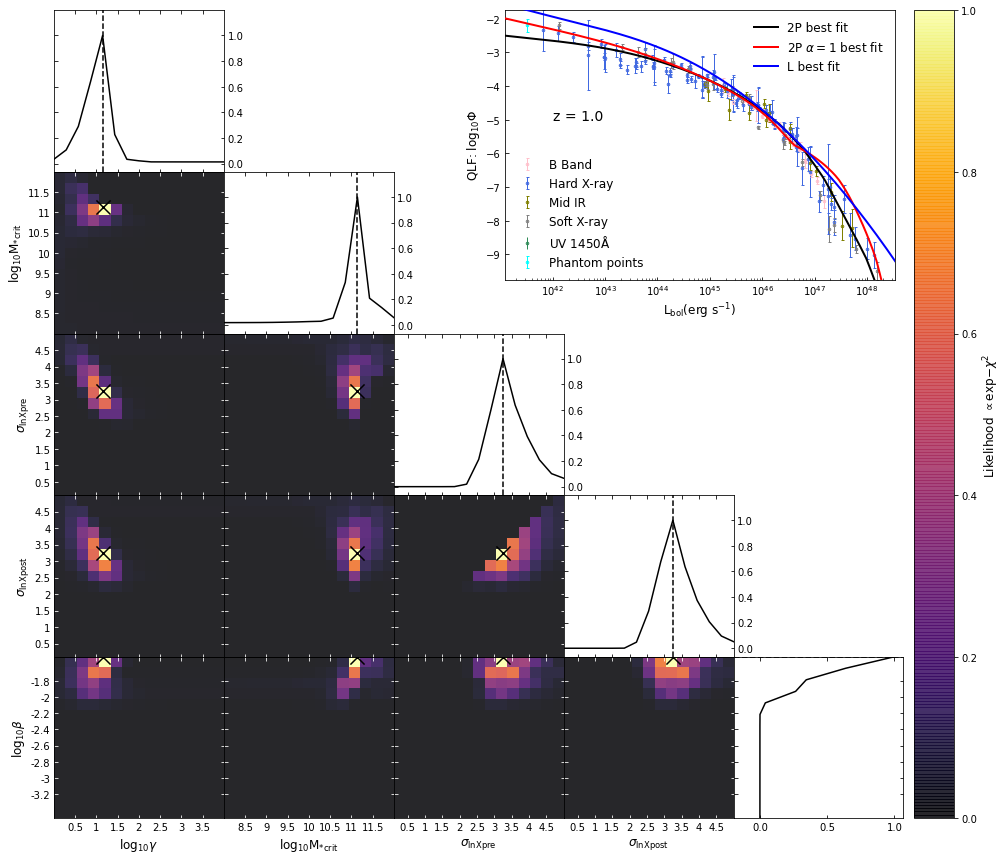

In [36]:
plt.close('all')


fig = plt.figure(figsize=(15,12))
gs = gridspec.GridSpec(5, 5)

likelihood = np.exp(-reduced_chi2_alpha1)

axj = [0,1,2,3,0,1,2,0,1,0]
axi = [4,4,4,4,3,3,3,2,2,1]
axes_l = []

extents = [[norm_from_local[0], norm_from_local[-1], norm_of_local[-1], norm_of_local[0]],\
           [transition[0], transition[-1], norm_of_local[-1], norm_of_local[0]],\
           [siglnX1[0], siglnX1[-1], norm_of_local[-1], norm_of_local[0]],\
           [siglnX2[0], siglnX2[-1], norm_of_local[-1], norm_of_local[0]],\
           [norm_from_local[0], norm_from_local[-1], siglnX2[-1], siglnX2[0]],\
           [transition[0], transition[-1], siglnX2[-1], siglnX2[0]],\
           [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]],\
           [norm_from_local[0], norm_from_local[-1], siglnX1[-1], siglnX1[0]],\
           [transition[0], transition[-1], siglnX1[-1], siglnX1[0]],\
           [norm_from_local[0], norm_from_local[-1], transition[-1], transition[0]],\
          ]

bl = ''  
norml = r'$\log_{10}\gamma$'
prel = r'$\sigma_{\ln{\rmXpre}}$'
postl = r'$\sigma_{\ln{\rmXpost}}$'
critl = r'$\log_{10}\rmM_{*crit}$'
locall = r'$\log_{10}\beta$'
xlabels = [norml, critl, prel, postl, bl, bl, bl, bl, bl, bl]
ylabels = [locall, bl, bl, bl, postl, bl, bl, prel, bl, critl]
slopet = [ 0.5, 1, 1.5, 2, 2.5, 3, 3.5]
normt = [0.5, 1, 1.5, 2, 2.5, 3, 3.5]
pret = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5]
postt = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5]
localt = [-3.2, -3, -2.8, -2.6, -2.4, -2.2, -2, -1.8]
critt = [8.5, 9, 9.5, 10, 10.5, 11, 11.5]
xticks = [normt, critt, pret, postt, normt, critt, pret,normt, critt, normt]
yticks = [localt, localt, localt, localt, postt, postt, postt, pret, pret, critt] 
indices = [0,1,2,3,4,5,6,7,8,9]
best_fits = [[gamma_fit_alpha1,beta_fit_alpha1],[crit_fit_alpha1,beta_fit_alpha1],[pre_fit_alpha1,beta_fit_alpha1],[post_fit_alpha1,beta_fit_alpha1],\
            [gamma_fit_alpha1,post_fit_alpha1],[crit_fit_alpha1,post_fit_alpha1],[pre_fit_alpha1,post_fit_alpha1],\
            [gamma_fit_alpha1,pre_fit_alpha1],[crit_fit_alpha1,pre_fit_alpha1],\
            [gamma_fit_alpha1,crit_fit_alpha1]]
for ind, i, j in zip(indices, axi, axj):   
        
    ### set up axis and label info
    ylabel = ylabels[ind]
    xlabel = xlabels[ind]
    extent = extents[ind]

                     
    ax = fig.add_subplot(gs[i, j])
    axes_l += [ax]
    ax.set_xlabel(xlabel,fontsize=12)
    ax.set_ylabel(ylabel,fontsize=12)
    ax.axis([extents[ind][0],extents[ind][1],extents[ind][3],extents[ind][2]])

    plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
    ax.set_xticklabels([str(i) for i in xticks[ind]])
    ax.set_yticklabels([str(i) for i in yticks[ind]])
        
    chi23d = likelihood
    if ind == 0:
        chi2_proj = np.zeros(chi23d[:,:,0,0,0,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,:,0,0,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, j, :, :, :, :])
        grid2d = chi2_proj

    elif ind == 1:
        chi2_proj = np.zeros(chi23d[:,0,0,0,0,:].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, :, :, :, j])
        grid2d = chi2_proj

    elif ind == 2:
        chi2_proj = np.zeros(chi23d[:,0,0,0,:,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, :, :, j, :])
        grid2d = chi2_proj

    elif ind == 3:
        chi2_proj = np.zeros(chi23d[:,0,0,:,0,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,:,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, :, j, :, :])
        grid2d = chi2_proj

    elif ind == 4:
        chi2_proj = np.zeros(chi23d[0,:,0,:,0,0].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,:,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, :, j, :, :])
        grid2d = chi2_proj.T

    elif ind == 5:
        chi2_proj = np.zeros(chi23d[0,0,0,:,0,:].shape)
        for i in range(len(chi23d[0,0,0,:,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, :, i, :, j])
        grid2d = chi2_proj

    elif ind == 6:
        chi2_proj = np.zeros(chi23d[0,0,0,:,:,0].shape)
        for i in range(len(chi23d[0,0,0,:,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, :, i, j, :])
        grid2d = chi2_proj

    elif ind == 7:
        chi2_proj = np.zeros(chi23d[0,:,0,0,:,0].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, :, :, j, :])
        grid2d = chi2_proj.T

    elif ind == 8:
        chi2_proj = np.zeros(chi23d[0,0,0,0,:,:].shape)
        for i in range(len(chi23d[0,0,0,0,:,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, :, :, i, j])
        grid2d = chi2_proj


    elif ind == 9:
        chi2_proj = np.zeros(chi23d[0,:,0,0,0,:].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, :, :, :, j])
        grid2d = chi2_proj.T
     
    vmax = 1
    norm = colors.Normalize(vmin = 0, vmax = vmax)

    cmap = matplotlib.cm.get_cmap('inferno')
    img = ax.imshow(grid2d/np.amax(grid2d), cmap = cmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, alpha=0.85)
    ax.scatter(best_fits[ind][0], best_fits[ind][1], marker = 'x', c='k', s=200)
    ax.tick_params(axis='both', direction='in',top=True,right=True,color='white')

plt.setp(axes_l[5].get_xticklabels(), visible=False)
plt.setp(axes_l[6].get_xticklabels(), visible=False)
plt.setp(axes_l[7].get_xticklabels(), visible=False)
plt.setp(axes_l[8].get_xticklabels(), visible=False)
plt.setp(axes_l[9].get_xticklabels(), visible=False)
plt.setp(axes_l[4].get_xticklabels(), visible=False)

plt.setp(axes_l[1].get_yticklabels(), visible=False)
plt.setp(axes_l[2].get_yticklabels(), visible=False)
plt.setp(axes_l[3].get_yticklabels(), visible=False)
plt.setp(axes_l[5].get_yticklabels(), visible=False)
plt.setp(axes_l[6].get_yticklabels(), visible=False)
plt.setp(axes_l[8].get_yticklabels(), visible=False)


axj = [0,1,2,3,4]
axi = [0,1,2,3,4]
ranges = [norm_from_local, transition, siglnX1, siglnX2, norm_of_local]
share = [axes_l[0], axes_l[1], axes_l[2], axes_l[3], axes_l[0]]
best_fits = [gamma_fit_alpha1, crit_fit_alpha1, pre_fit_alpha1, post_fit_alpha1, beta_fit_alpha1]
inds = [0,1,2,3,4]

for ind, i, j in zip(inds, axi, axj):    
    if ind == 0:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,:,0,0,0,0].shape)
        for k in range(len(chi23d[0,:,0,0,0,0])):
            proj[k] = np.amax(chi23d[:,k,:,:,:,:])
    elif ind == 1:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,0,0,0,:].shape)
        for k in range(len(chi23d[0,0,0,0,0,:])):
            proj[k] = np.amax(chi23d[:,:,:,:,:,k])
    elif ind == 2:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,0,0,:,0].shape)
        for k in range(len(chi23d[0,0,0,0,:,0])):
            proj[k] = np.amax(chi23d[:,:,:,:,k,:])
    elif ind == 3:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,0,:,0,0].shape)
        for k in range(len(chi23d[0,0,0,:,0,0])):
            proj[k] = np.amax(chi23d[:,:,:,k,:,:])
    elif ind == 4:
        ax = fig.add_subplot(gs[i, j],sharey = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[:,0,0,0,0,0].shape)
        for k in range(len(chi23d[:,0,0,0,0,0])):
            proj[k] = np.amax(chi23d[k,:,:,:,:,:])
    
    proj = proj/max(proj)
    if ind != 4:
        ax.plot(ranges[ind], proj, c='k')
        ax.set_ylim([0-max(proj)/15.1,max(proj)+max(proj)/5.1])
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
        ax.tick_params(axis='both', direction='in',top=True,right=True, left=True,color='k')
        plt.setp(ax.get_xticklabels(), visible=False)
        ax.axvline(best_fits[ind], c='k', ls='dashed')
    else:
        ax.plot(proj, ranges[ind],c='k')
        ax.tick_params(axis='both', direction='in',right=True, top=True, bottom=True,color='k')
        ax.set_xlim([0-max(proj)/5.1,max(proj)+max(proj)/15.1])
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.axhline(best_fits[ind], c='k', ls='dashed')

        

gs2 = gridspec.GridSpec(6, 3)
gs2.update(left=0.55, right=0.98)
ax = fig.add_subplot(gs2[0:2,:])
axes_l.append(ax)

bins = 0.0005
z = 1.0
lums = np.linspace(5,18,200)
lumsp = 10**lums*3.8e33

qlf = QLF_Lcap(z, bins)
qlf.get_Mbh(crit_fit, alpha_fit, gamma_fit, norm_local = 11+beta_fit)
qlf.get_dNdlnL(lums, [pre_fit, post_fit])
ax.plot(lumsp, np.log10(qlf.dNdlogL), c='k', label = '2P best fit', lw=2, zorder=10)

qlf = QLF_Lcap(z, bins)
qlf.get_Mbh(crit_fit_alpha1, alpha_fit_alpha1, gamma_fit_alpha1, norm_local = 11+beta_fit_alpha1)
qlf.get_dNdlnL(lums, [pre_fit_alpha1, post_fit_alpha1])
ax.plot(lumsp, np.log10(qlf.dNdlogL), c='r', label = r'2P $\alpha=1$ best fit', lw=2, zorder = 10)

qlf = QLF(z, bins)
qlf.get_Mbh(3, 1, 0, norm_local = 11-2.8)
qlf.get_dNdlnL(lums, [2.4, 2.4])
ax.plot(lumsp, np.log10(qlf.dNdlogL), c='b', label = r'L best fit', lw=2, zorder=10)




objs, labels = plot_obs(ax, phantom = True)

ax.axis([10**7.5*3.8e33,10**14.95*3.8e33,-9.75,-1.75])
ax.set_xlabel(r'$\rmL_{bol} (erg\ s^{-1})$', fontsize=12)
ax.set_ylabel(r'QLF: $\log_{10} \Phi$', fontsize =12)
ax.text(10**42,-5,'z = '+str(z), fontsize = 14)
ax.set_xscale('log')
ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
legend = ax.legend(fontsize=12, loc='upper right', framealpha=0)
legendB = ax.legend(handles = objs, labels=labels, fontsize = 12, loc='lower left', framealpha=0)
ax.add_artist(legend)

plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
cbar = plt.colorbar(img, pad = 0.01, ax = axes_l).set_label(label=r'Likelihood $\propto \exp{-\chi ^2}$ ',size=12)

        
plt.savefig('../ceph/QLF_proj/PLOTS/bivariate-likelihood_phantom-fixed_Lcap_lowres-alpha1.pdf')